# **Obtención de resultados con los datos de los entrenos**

In [1]:
%load_ext autoreload
%autoreload 2

import time
import sympy
import numpy as np
from math import log, log2

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.optimize import curve_fit


import pandas as pd
import pickle

from Crypto.Util import number


from tqdm.notebook import tqdm

import random

from scipy.optimize import curve_fit, least_squares

#Importar de función interna
from modules import schnorr_lattice as sl
from modules import qaoa
from modules import utils

from modules.functions import solve_cvp, solve_cvp_with_opt_paramters

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)

In [3]:
def scaling_function(x, alpha):
    return 1/(2**(alpha*x))

In [4]:
def generate_results_validation_set(minimum, maximum, n_per_length):
    conjunto = []
    bitlengths = []


    for bit_length in range(minimum, maximum):
        for _ in range(n_per_length):
            N = utils.generate_N(bit_length)

            conjunto.append(N)
            bitlengths.append(bit_length)

    
    df = pd.DataFrame({
        'N': conjunto,
        'Bit_length': bitlengths
    })

    return df


In [5]:
def obtain_data(vnews, instance, b_op, N, n, bitlength,
                probs):

    #Calculo el modulo al cuadrado para comparar las distancias obtenidas
    distances = utils.get_distances2(vnews, instance.t)

    #Calculo la distancia del vector aproximado obtenido clasicamente
    res_vector = np.subtract(b_op, instance.t)
    aprox_distance = np.dot(res_vector, res_vector)

    #Inicializo las variables para vector mas cercano encontrado, vectores simulares al aproximado y vectores mas cortos que el aproximado
    best_distance_prob = 0
    best_distance = np.inf

    aprox_sol_prob = 0

    improve_prob = 0

    for i in range(len(vnews)):

        if distances[i] == aprox_distance: 
            aprox_sol_prob += probs[i]

        if distances[i] < aprox_distance:
            improve_prob += probs[i]
        
        if distances[i] < best_distance:
            best_distance_prob = probs[i]
            best_distance = distances[i]
        elif distances[i] == best_distance: 
            best_distance_prob += probs[i]

    
    return pd.DataFrame({
        'Bit_length':[bitlength],
        'N': [N],
        'Lattice_dimension': [n],
        '|b_op - t|^2': [aprox_distance],
        '|vbest - t|^2': [best_distance],
        'P(b_op)': [aprox_sol_prob],
        'P(vbest)': [best_distance_prob],
        'P(|vnew - t|^2 < |b_op - t|^2)': [improve_prob],
        'P(|vnew - t|^2 <= |b_op - t|^2)': [improve_prob + aprox_sol_prob],
        'P(|vnew - t|^2 > |b_op - t|^2)' : [1 - (improve_prob + aprox_sol_prob)]
    })

In [5]:
def get_empty_df():
    return pd.DataFrame({
            'Bit_length':[],
            'N': [],
            'Lattice_dimension': [],
            '|b_op - t|^2': [],
            '|vbest - t|^2': [],
            'P(b_op)': [],
            'P(vbest)': [],
            'P(|vnew - t|^2 < |b_op - t|^2)': [],
            'P(|vnew - t|^2 <= |b_op - t|^2)': [],
            'P(|vnew - t|^2 > |b_op - t|^2)' : []
        })

In [6]:
def obtain_data_from_valList(res_val_set,
                            infile1: str, infile2: str, outfile1: str, outfile2: str,
                            c, l, seed, set_seed = False, q = 10, normalizeHc = True, delta = 0.75,
                            verbose = False, progress_bar = True):
    
    np.random.seed(seed)

    for p in  tqdm(range(1, 11), desc = 'Escalabilidad') if progress_bar else range(1, 11):

        nelder_df = get_empty_df()
        cobyla_df = get_empty_df()

        with open(f"{infile1}{p}.pkl", "rb") as f:
            angles_nelder = pickle.load(f)
        with open(f"{infile2}{p}.pkl", "rb") as f:
            angles_cobyla = pickle.load(f)

        angles_nelder_list = list(angles_nelder.values())
        angles_cobyla_list = list(angles_cobyla.values())

        for N in res_val_set:
            cvp = sl.schnorrCVP(N, c = c, l = l, seed = seed, set_seed = set_seed, verbose = verbose)
            instance = cvp.generate_cvp(q = q, verbose = verbose)
        
            vnews, probs, b_op, _ = solve_cvp_with_opt_paramters(cvp, instance, angles_nelder_list, delta = delta, normalize = normalizeHc, p = p)
            sol = obtain_data(vnews, instance, b_op, N, cvp.n, cvp.m, probs)
            nelder_df = pd.concat([nelder_df, sol], ignore_index= True)

            vnews, probs, b_op, _ = solve_cvp_with_opt_paramters(cvp, instance, angles_cobyla_list, delta = delta, normalize = normalizeHc, p = p)
            sol = obtain_data(vnews, instance, b_op, N, cvp.n, cvp.m, probs)
            cobyla_df = pd.concat([cobyla_df, sol], ignore_index= True)
        
        nelder_df.to_csv(f"{outfile1}{p}.csv", index = False)
        cobyla_df.to_csv(f"{outfile2}{p}.csv", index = False)   

## **Generación de datos**

In [ ]:
minimum = 8
maximum = 128
n_per_length = 10
setLength = (maximum + 1 - minimum)*n_per_length

#Ejecutado solo para generar un conjunto de validacion final para observar como escala los angulos que hemos encontrado
res_val_df1 = generate_results_validation_set(minimum, maximum + 1, n_per_length)

res_val_df1.to_csv(f'results_vals_sets/resultsValidation_set_size{setLength}_{minimum}to{maximum}_{n_per_length}reps.csv', index = False)

In [13]:
minimum = 9
maximum = 128
n_per_length = 20
setLength = (maximum + 1 - minimum)*n_per_length
#Ejecutado solo para generar un conjunto de validacion final para observar como escala los angulos que hemos encontrado
res_val_df1 = generate_results_validation_set(minimum, maximum + 1, n_per_length)

res_val_df1.to_csv(f'results_vals_sets/resultsValidation_set_size{setLength}_{minimum}to{maximum}_{n_per_length}reps.csv', index = False)

## **Entrenamiento 1**

En la siguiente seccion se va a validar cómo de buenos son los ángulos calculados en la sección de entrenamiento tanto para COBYLA  como Nelder-Mead

### Obtener los datos 1.1

In [ ]:
minimum = 8
maximum = 128
n_per_length = 10
setLength = (maximum + 1 - minimum)*n_per_length
res_val_df1 = pd.read_csv(f'results_vals_sets/resultsValidation_set_size{setLength}_{minimum}to{maximum}_{n_per_length}reps.csv')
res_val_set = res_val_df1['N'].to_numpy()

In [ ]:
# ~30 minutos
obtain_data_from_valList(res_val_set,
                         "./results/optimal_angles/train10_val242_NelderMead_p",
                         "./results/optimal_angles/train10_val242_COBYLA_p",
                         f"./results/scalability_results/datas{setLength}_from{minimum}to{maximum}_1_NelderMead_p",
                         f"./results/scalability_results/datas{setLength}_from{minimum}to{maximum}_1_COBYLA_p",
                         c = 3, l = 1, seed = seed, set_seed = False, q = 10, normalizeHc = True, delta = 0.75, 
                         verbose = False, progress_bar = True)

Escalabilidad:   0%|          | 0/10 [00:00<?, ?it/s]

### Obtener los datos 1.2

In [13]:
minimum = 9
maximum = 128
n_per_length = 20
setLength = (maximum + 1 - minimum)*n_per_length
res_val_df1 = pd.read_csv(f'results_vals_sets/resultsValidation_set_size{setLength}_{minimum}to{maximum}_{n_per_length}reps.csv')
res_val_set = res_val_df1['N'].to_numpy()

In [ ]:
# ~1 hora
obtain_data_from_valList(res_val_set,
                         "./results/optimal_angles/train10_val242_NelderMead_p",
                         "./results/optimal_angles/train10_val242_COBYLA_p",
                         f"./results/scalability_results/datas{setLength}_from{minimum}to{maximum}_1_NelderMead_p",
                         f"./results/scalability_results/datas{setLength}_from{minimum}to{maximum}_1_COBYLA_p",
                         c = 3, l = 1, seed = seed, set_seed = False, q = 10, normalizeHc = True, delta = 0.75, 
                         verbose = False, progress_bar = True)

Escalabilidad:   0%|          | 0/10 [00:00<?, ?it/s]

## **Entrenamiento 2**

### Obtener los datos 2.1

In [11]:
minimum = 8
maximum = 128
n_per_length = 10
setLength = (maximum + 1 - minimum)*n_per_length
res_val_df1 = pd.read_csv(f'results_vals_sets/resultsValidation_set_size{setLength}_{minimum}to{maximum}_{n_per_length}reps.csv')
res_val_set = res_val_df1['N'].to_numpy()


In [ ]:
# ~30 minutos
obtain_data_from_valList(res_val_set,
                         "./results/optimal_angles/train50_val480_NelderMead_p",
                         "./results/optimal_angles/train50_val480_COBYLA_p",
                         f"./results/scalability_results/datas{setLength}_from{minimum}to{maximum}_2_NelderMead_p",
                         f"./results/scalability_results/datas{setLength}_from{minimum}to{maximum}_2_COBYLA_p",
                         c = 4, l = 1, seed = seed, set_seed = False, q = 10, normalizeHc = True, delta = 0.75, 
                         verbose = False, progress_bar = True)

Escalabilidad:   0%|          | 0/10 [00:00<?, ?it/s]

### Obtener los datos 2.2

In [7]:
minimum = 9
maximum = 128
n_per_length = 20
setLength = (maximum + 1 - minimum)*n_per_length
res_val_df1 = pd.read_csv(f'results_vals_sets/resultsValidation_set_size{setLength}_{minimum}to{maximum}_{n_per_length}reps.csv')
res_val_set = res_val_df1['N'].to_numpy()

In [8]:
# ~1 hora
obtain_data_from_valList(res_val_set,
                         "./results/optimal_angles/train50_val480_NelderMead_p",
                         "./results/optimal_angles/train50_val480_COBYLA_p",
                         f"./results/scalability_results/datas{setLength}_from{minimum}to{maximum}_2_NelderMead_p",
                         f"./results/scalability_results/datas{setLength}_from{minimum}to{maximum}_2_COBYLA_p",
                         c = 4, l = 1, seed = seed, set_seed = False, q = 10, normalizeHc = True, delta = 0.75, 
                         verbose = False, progress_bar = True)

Escalabilidad:   0%|          | 0/10 [00:00<?, ?it/s]

## **Evaluación de los resultados**

In [6]:
sns.set_theme(style="darkgrid", context = "notebook")
PALETTE = sns.color_palette("tab10", 10) 

In [7]:
n_cols = 2
n_rows = 5

### Entrenamiento 1

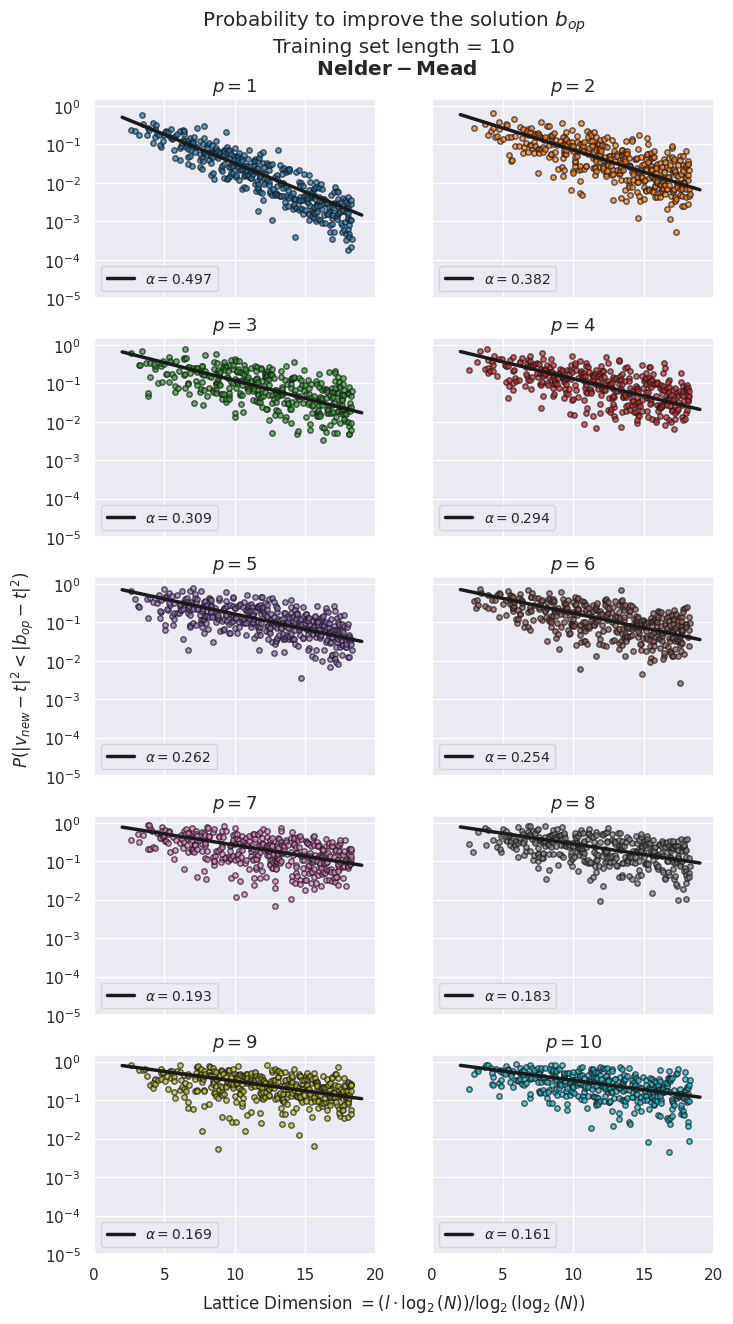

In [41]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(8, 15),
    sharey = 'row', sharex = 'col'
)
axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1 
    ax = axes_flat[idx]
    color = PALETTE[idx]

    nelder_df = pd.read_csv(f"./results/scalability_results/datas1210_from8to128_1_NelderMead_p{p}.csv")

    #Tomo las probabilidades donde se ha encontrado vectores mejores
    nel_prob_positive = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    lattice_dimension = nel_prob_positive["Lattice_dimension"].to_numpy()
    probs = nel_prob_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    dimension_exacta = np.log2(nel_prob_positive["N"].to_numpy())/np.log2(np.log2(nel_prob_positive["N"].to_numpy()))

    ax.scatter(
        dimension_exacta, probs,
        color=color, s=15, zorder=2,
        edgecolor = 'k', alpha = 0.7
    )

    alpha = curve_fit(scaling_function, xdata = dimension_exacta, ydata = probs)[0][0]
 
 
    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)
    ys_successful = [scaling_function(x, alpha) for x in xs]

    sns.lineplot(x=xs, y=ys_successful, color='k', ax=ax, label=f'$\\alpha={alpha:.3f}$', zorder = 4, linewidth = 2.5)


    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])
    ax.legend(fontsize=10, loc="lower left")
    

fig.suptitle(
    "Probability to improve the solution $b_{op}$\nTraining set length = 10\n $\mathbf{Nelder-Mead}$",
    y=0.94
)

fig.supylabel(
    r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
    fontsize=12,
    x=0.02  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.07  
)

plt.savefig('./figures/scalability_datas1210_from8to128_1_NelderMead.png', dpi=300, bbox_inches='tight')
plt.show()


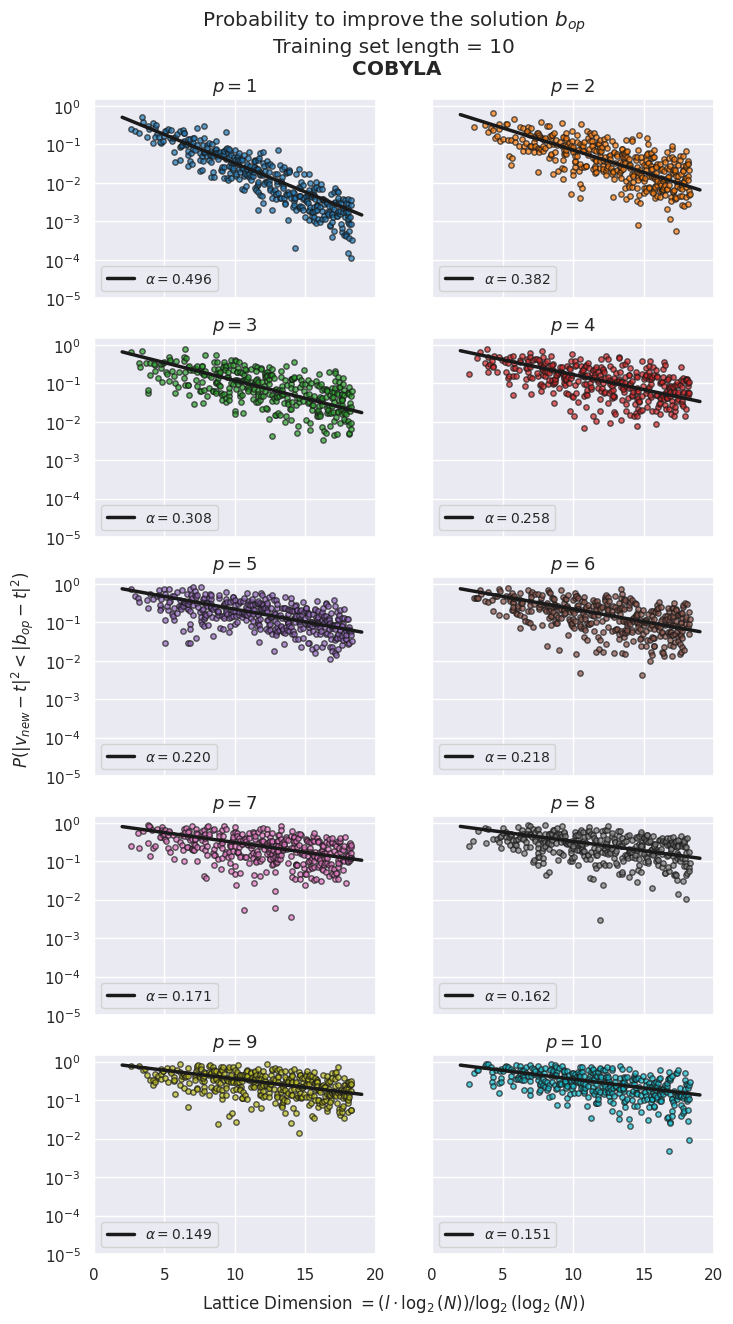

In [42]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(8, 15),
    sharey = 'row', sharex = 'col'
)
axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1 
    ax = axes_flat[idx]
    color = PALETTE[idx]

    nelder_df = pd.read_csv(f"./results/scalability_results/datas1210_from8to128_1_COBYLA_p{p}.csv")

    #Tomo las probabilidades donde se ha encontrado vectores mejores
    nel_prob_positive = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    lattice_dimension = nel_prob_positive["Lattice_dimension"].to_numpy()
    probs = nel_prob_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    dimension_exacta = np.log2(nel_prob_positive["N"].to_numpy())/np.log2(np.log2(nel_prob_positive["N"].to_numpy()))

    ax.scatter(
        dimension_exacta, probs,
        color=color, s=15, zorder=2,
        edgecolor = 'k', alpha = 0.7
    )

    alpha = curve_fit(scaling_function, xdata = dimension_exacta, ydata = probs)[0][0]
 
 
    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)
    ys_successful = [scaling_function(x, alpha) for x in xs]

    sns.lineplot(x=xs, y=ys_successful, color='k', ax=ax, label=f'$\\alpha={alpha:.3f}$', zorder = 4, linewidth = 2.5)


    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])
    ax.legend(fontsize=10, loc="lower left")
    

fig.suptitle(
    "Probability to improve the solution $b_{op}$\nTraining set length = 10\n $\mathbf{COBYLA}$",
    y=0.94
)

fig.supylabel(
    r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
    fontsize=12,
    x=0.02  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.07  
)

plt.savefig('./figures/scalability_datas1210_from8to128_1_COBYLA.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
for p in range(1, 11):
    cobyla_df = pd.read_csv(f"./results/scalability_results/datas1210_from8to128_1_COBYLA_p{p}.csv")
    nelder_df = pd.read_csv(f"./results/scalability_results/datas1210_from8to128_1_NelderMead_p{p}.csv")

    cob_prob_pos = cobyla_df[cobyla_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    nel_prob_pos = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    alpha_cob = curve_fit(scaling_function, xdata = cob_prob_pos["Lattice_dimension"].to_numpy(), ydata = cob_prob_pos["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy())[0][0]
    alpha_nel = curve_fit(scaling_function, xdata = nel_prob_pos["Lattice_dimension"].to_numpy(), ydata = nel_prob_pos["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy())[0][0]


    print(f"p = {p}. COBYLA = {alpha_cob}")
    print(f"p = {p}. NelderMead = {alpha_nel}")


p = 1. COBYLA = 0.49810213897307853
p = 1. NelderMead = 0.49841314526258496
p = 2. COBYLA = 0.38284988046823737
p = 2. NelderMead = 0.3823646767314082
p = 3. COBYLA = 0.30828039086018444
p = 3. NelderMead = 0.30902456031834696
p = 4. COBYLA = 0.2575383626265002
p = 4. NelderMead = 0.29374171349339606
p = 5. COBYLA = 0.2192945998237638
p = 5. NelderMead = 0.26149822442202064
p = 6. COBYLA = 0.21780666864715922
p = 6. NelderMead = 0.2537351195442436
p = 7. COBYLA = 0.17071932962409675
p = 7. NelderMead = 0.19326796660934614
p = 8. COBYLA = 0.16178082449741685
p = 8. NelderMead = 0.18323895728793668
p = 9. COBYLA = 0.14851885176848914
p = 9. NelderMead = 0.16857553538530726
p = 10. COBYLA = 0.1510721027819593
p = 10. NelderMead = 0.1609531494892804


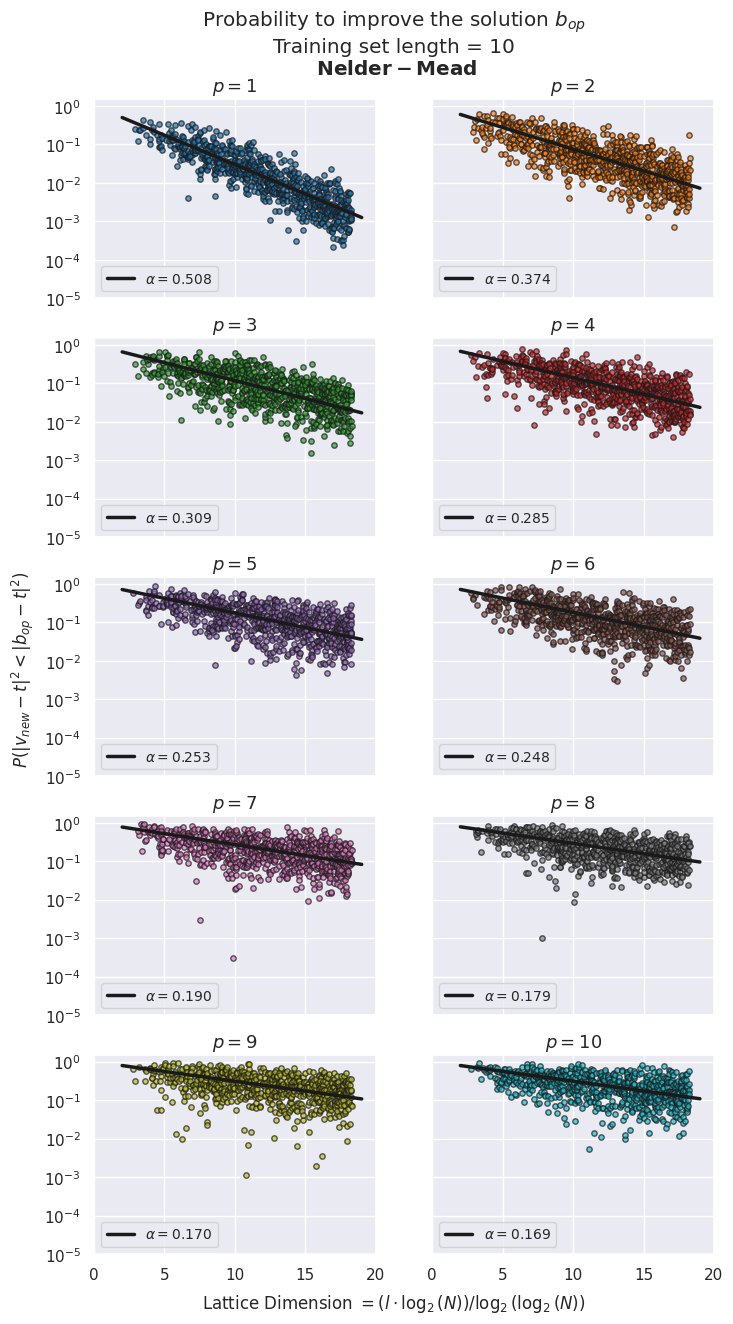

In [45]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(8, 15),
    sharey = 'row', sharex = 'col'
)
axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1 
    ax = axes_flat[idx]
    color = PALETTE[idx]

    nelder_df = pd.read_csv(f"./results/scalability_results/datas2400_from9to128_1_NelderMead_p{p}.csv")

    #Tomo las probabilidades donde se ha encontrado vectores mejores
    nel_prob_positive = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    lattice_dimension = nel_prob_positive["Lattice_dimension"].to_numpy()
    probs = nel_prob_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    dimension_exacta = np.log2(nel_prob_positive["N"].to_numpy())/np.log2(np.log2(nel_prob_positive["N"].to_numpy()))

    ax.scatter(
        dimension_exacta, probs,
        color=color, s=15, zorder=2,
        edgecolor = 'k', alpha = 0.7
    )

    alpha = curve_fit(scaling_function, xdata = dimension_exacta, ydata = probs)[0][0]
 
 
    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)
    ys_successful = [scaling_function(x, alpha) for x in xs]

    sns.lineplot(x=xs, y=ys_successful, color='k', ax=ax, label=f'$\\alpha={alpha:.3f}$', zorder = 4, linewidth = 2.5)


    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])
    ax.legend(fontsize=10, loc="lower left")
    

fig.suptitle(
    "Probability to improve the solution $b_{op}$\nTraining set length = 10\n $\mathbf{Nelder-Mead}$",
    y=0.94
)

fig.supylabel(
    r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
    fontsize=12,
    x=0.02  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.07  
)

plt.savefig('./figures/scalability_datas2400_from9to128_1_NelderMead.png', dpi=300, bbox_inches='tight')
plt.show()


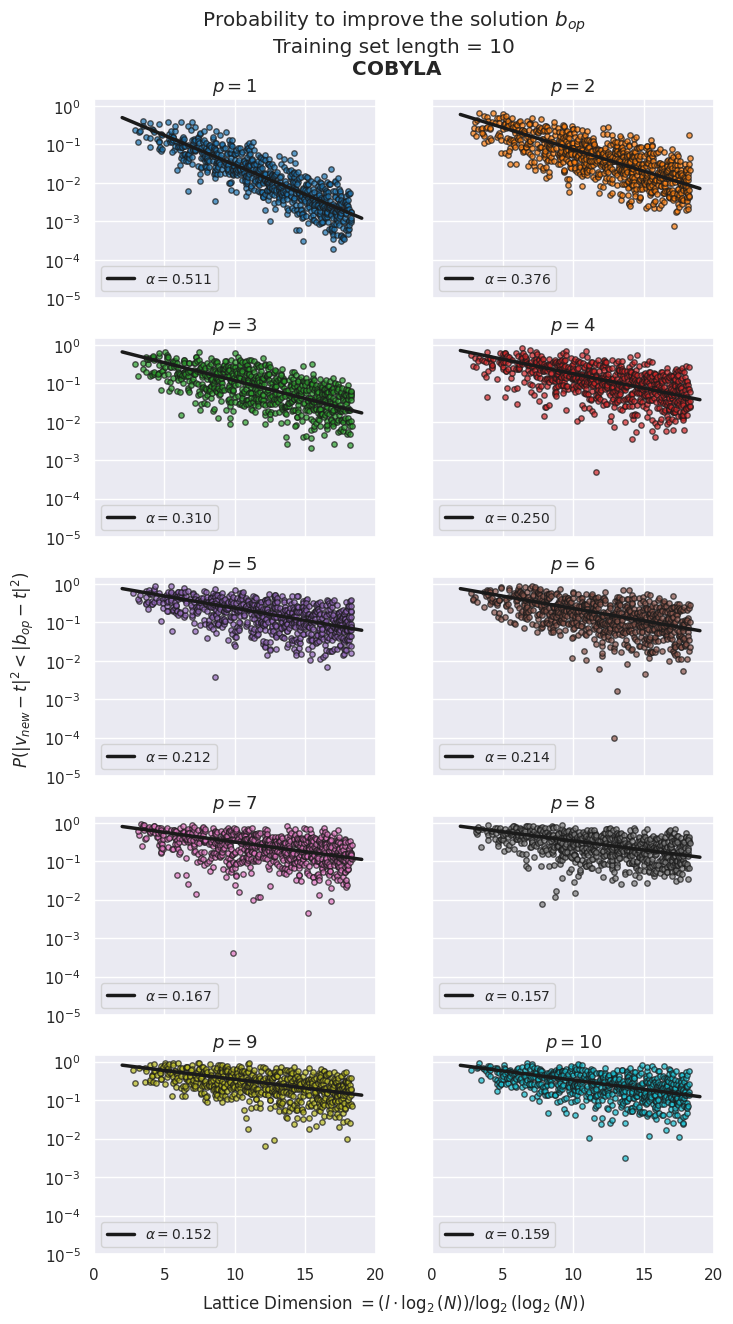

In [46]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(8, 15),
    sharey = 'row', sharex = 'col'
)
axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1 
    ax = axes_flat[idx]
    color = PALETTE[idx]

    nelder_df = pd.read_csv(f"./results/scalability_results/datas2400_from9to128_1_COBYLA_p{p}.csv")

    #Tomo las probabilidades donde se ha encontrado vectores mejores
    nel_prob_positive = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    lattice_dimension = nel_prob_positive["Lattice_dimension"].to_numpy()
    probs = nel_prob_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    dimension_exacta = np.log2(nel_prob_positive["N"].to_numpy())/np.log2(np.log2(nel_prob_positive["N"].to_numpy()))

    ax.scatter(
        dimension_exacta, probs,
        color=color, s=15, zorder=2,
        edgecolor = 'k', alpha = 0.7
    )

    alpha = curve_fit(scaling_function, xdata = dimension_exacta, ydata = probs)[0][0]
 
 
    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)
    ys_successful = [scaling_function(x, alpha) for x in xs]

    sns.lineplot(x=xs, y=ys_successful, color='k', ax=ax, label=f'$\\alpha={alpha:.3f}$', zorder = 4, linewidth = 2.5)


    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])
    ax.legend(fontsize=10, loc="lower left")
    

fig.suptitle(
    "Probability to improve the solution $b_{op}$\nTraining set length = 10\n $\mathbf{COBYLA}$",
    y=0.94
)

fig.supylabel(
    r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
    fontsize=12,
    x=0.02  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.07  
)

plt.savefig('./figures/scalability_datas2400_from9to128_1_COBYLA.png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
for p in range(1, 11):
    cobyla_df = pd.read_csv(f"./results/scalability_results/datas2400_from9to128_1_COBYLA_p{p}.csv")
    nelder_df = pd.read_csv(f"./results/scalability_results/datas2400_from9to128_1_NelderMead_p{p}.csv")

    cob_prob_pos = cobyla_df[cobyla_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    nel_prob_pos = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    alpha_cob = curve_fit(scaling_function, xdata = cob_prob_pos["Lattice_dimension"].to_numpy(), ydata = cob_prob_pos["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy())[0][0]
    alpha_nel = curve_fit(scaling_function, xdata = nel_prob_pos["Lattice_dimension"].to_numpy(), ydata = nel_prob_pos["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy())[0][0]


    print(f"p = {p}. COBYLA = {alpha_cob}")
    print(f"p = {p}. NelderMead = {alpha_nel}")

p = 1. COBYLA = 0.5125468488418504
p = 1. NelderMead = 0.5094648769904665
p = 2. COBYLA = 0.37689640222133264
p = 2. NelderMead = 0.3753795781506014
p = 3. COBYLA = 0.3095485362270746
p = 3. NelderMead = 0.30912071766389415
p = 4. COBYLA = 0.2502088395447503
p = 4. NelderMead = 0.2849832677450273
p = 5. COBYLA = 0.21226136359786027
p = 5. NelderMead = 0.25387600206159167
p = 6. COBYLA = 0.21350026287484872
p = 6. NelderMead = 0.24753434289504372
p = 7. COBYLA = 0.1666944376758056
p = 7. NelderMead = 0.18946271316969476
p = 8. COBYLA = 0.15699192675385873
p = 8. NelderMead = 0.17878779315458726
p = 9. COBYLA = 0.152310261559729
p = 9. NelderMead = 0.16949804483794792
p = 10. COBYLA = 0.15930834207166927
p = 10. NelderMead = 0.16889110515868683


### Entrenamiento 2

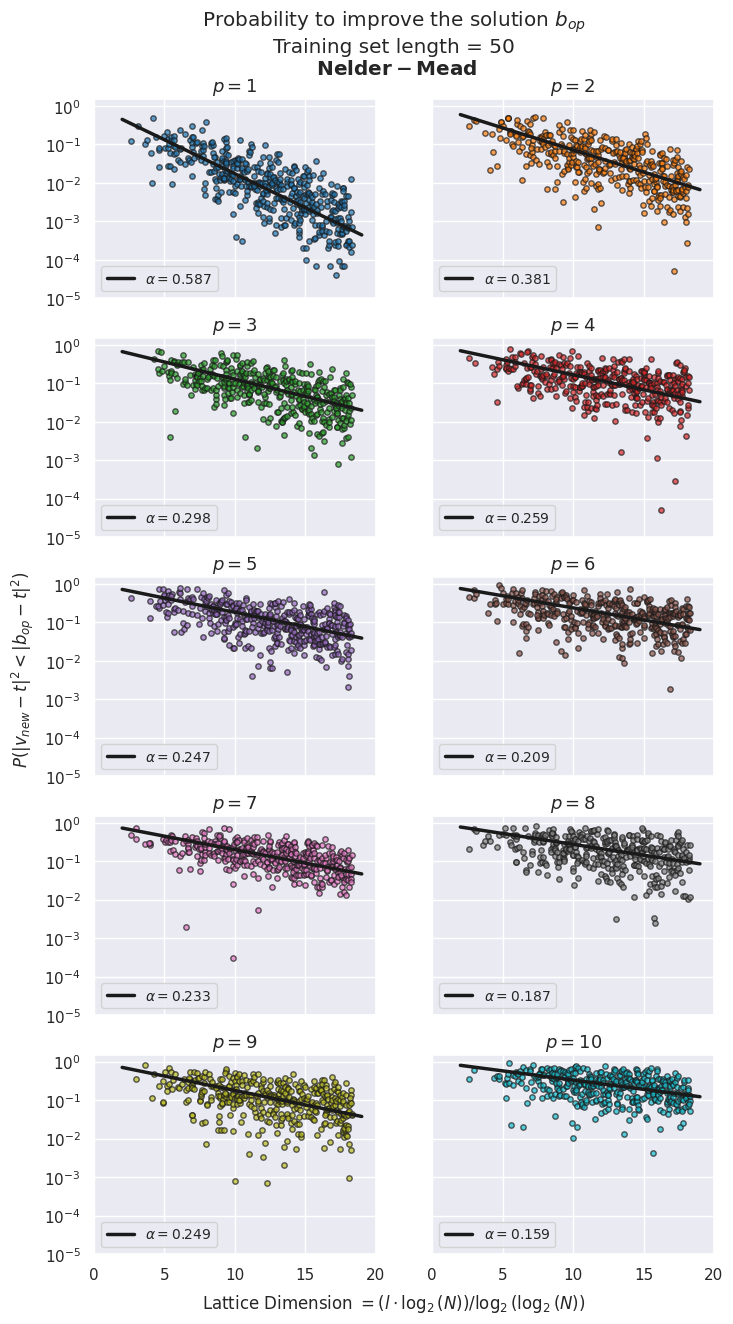

In [48]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(8, 15),
    sharey = 'row', sharex = 'col'
)
axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1 
    ax = axes_flat[idx]
    color = PALETTE[idx]

    nelder_df = pd.read_csv(f"./results/scalability_results/datas1210_from8to128_2_NelderMead_p{p}.csv")

    #Tomo las probabilidades donde se ha encontrado vectores mejores
    nel_prob_positive = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    lattice_dimension = nel_prob_positive["Lattice_dimension"].to_numpy()
    probs = nel_prob_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    dimension_exacta = np.log2(nel_prob_positive["N"].to_numpy())/np.log2(np.log2(nel_prob_positive["N"].to_numpy()))

    ax.scatter(
        dimension_exacta, probs,
        color=color, s=15, zorder=2,
        edgecolor = 'k', alpha = 0.7
    )

    alpha = curve_fit(scaling_function, xdata = dimension_exacta, ydata = probs)[0][0]
 
 
    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)
    ys_successful = [scaling_function(x, alpha) for x in xs]

    sns.lineplot(x=xs, y=ys_successful, color='k', ax=ax, label=f'$\\alpha={alpha:.3f}$', zorder = 4, linewidth = 2.5)


    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])
    ax.legend(fontsize=10, loc="lower left")
    

fig.suptitle(
    "Probability to improve the solution $b_{op}$\nTraining set length = 50\n $\mathbf{Nelder-Mead}$",
    y=0.94
)

fig.supylabel(
    r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
    fontsize=12,
    x=0.02  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.07  
)

plt.savefig('./figures/scalability_datas1210_from8to128_2_NelderMead.png', dpi=300, bbox_inches='tight')
plt.show()


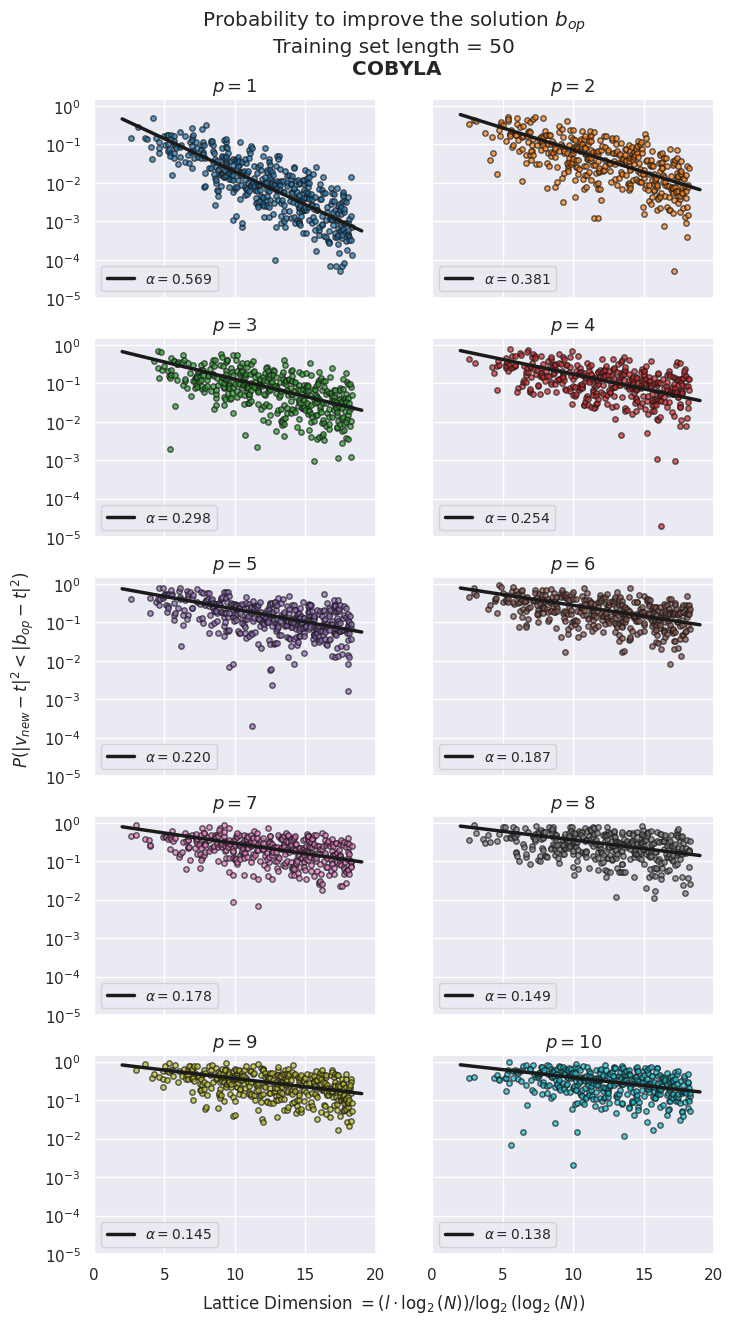

In [49]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(8, 15),
    sharey = 'row', sharex = 'col'
)
axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1 
    ax = axes_flat[idx]
    color = PALETTE[idx]

    nelder_df = pd.read_csv(f"./results/scalability_results/datas1210_from8to128_2_COBYLA_p{p}.csv")

    #Tomo las probabilidades donde se ha encontrado vectores mejores
    nel_prob_positive = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    lattice_dimension = nel_prob_positive["Lattice_dimension"].to_numpy()
    probs = nel_prob_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    dimension_exacta = np.log2(nel_prob_positive["N"].to_numpy())/np.log2(np.log2(nel_prob_positive["N"].to_numpy()))

    ax.scatter(
        dimension_exacta, probs,
        color=color, s=15, zorder=2,
        edgecolor = 'k', alpha = 0.7
    )

    alpha = curve_fit(scaling_function, xdata = dimension_exacta, ydata = probs)[0][0]
 
 
    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)
    ys_successful = [scaling_function(x, alpha) for x in xs]

    sns.lineplot(x=xs, y=ys_successful, color='k', ax=ax, label=f'$\\alpha={alpha:.3f}$', zorder = 4, linewidth = 2.5)


    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])
    ax.legend(fontsize=10, loc="lower left")
    

fig.suptitle(
    "Probability to improve the solution $b_{op}$\nTraining set length = 50\n $\mathbf{COBYLA}$",
    y=0.94
)

fig.supylabel(
    r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
    fontsize=12,
    x=0.02  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.07  
)

plt.savefig('./figures/scalability_datas1210_from8to128_2_COBYLA.png', dpi=300, bbox_inches='tight')
plt.show()


In [15]:
for p in range(1, 11):
    cobyla_df = pd.read_csv(f"./results/scalability_results/datas1210_from8to128_2_COBYLA_p{p}.csv")
    nelder_df = pd.read_csv(f"./results/scalability_results/datas1210_from8to128_2_NelderMead_p{p}.csv")

    cob_prob_pos = cobyla_df[cobyla_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    nel_prob_pos = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    alpha_cob = curve_fit(scaling_function, xdata = cob_prob_pos["Lattice_dimension"].to_numpy(), ydata = cob_prob_pos["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy())[0][0]
    alpha_nel = curve_fit(scaling_function, xdata = nel_prob_pos["Lattice_dimension"].to_numpy(), ydata = nel_prob_pos["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy())[0][0]


    print(f"p = {p}. COBYLA = {alpha_cob}")
    print(f"p = {p}. NelderMead = {alpha_nel}")


p = 1. COBYLA = 0.5659079120752448
p = 1. NelderMead = 0.5832569796055697
p = 2. COBYLA = 0.3812824068808241
p = 2. NelderMead = 0.38127469149145393
p = 3. COBYLA = 0.2985795255621854
p = 3. NelderMead = 0.29859372747070073
p = 4. COBYLA = 0.25308375945458095
p = 4. NelderMead = 0.25835543191044075
p = 5. COBYLA = 0.21956283671832627
p = 5. NelderMead = 0.24720108844102595
p = 6. COBYLA = 0.18697831981603535
p = 6. NelderMead = 0.2089976008264174
p = 7. COBYLA = 0.1781384895296366
p = 7. NelderMead = 0.23238862532617385
p = 8. COBYLA = 0.1490104718616606
p = 8. NelderMead = 0.18681301088149682
p = 9. COBYLA = 0.1450028498097561
p = 9. NelderMead = 0.2486025383414451
p = 10. COBYLA = 0.1375249647686289
p = 10. NelderMead = 0.15936528335696873


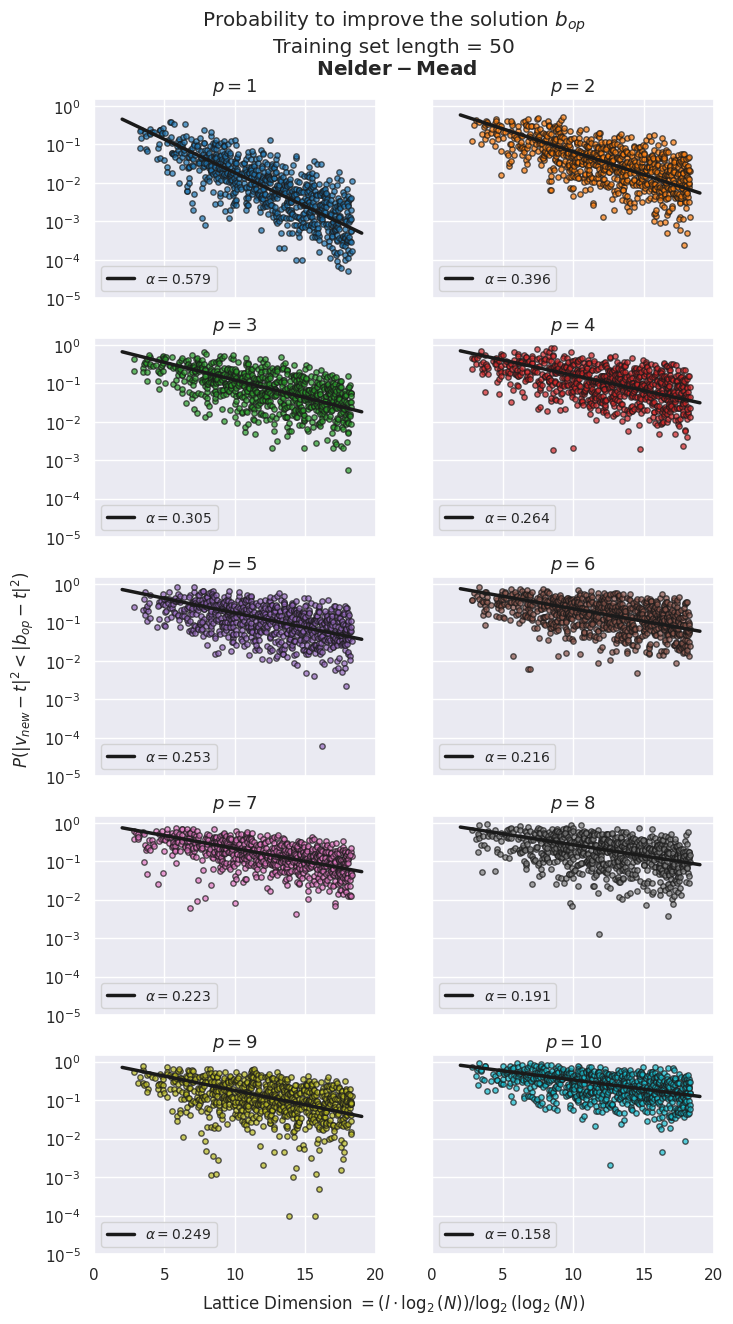

In [51]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(8, 15),
    sharey = 'row', sharex = 'col'
)
axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1 
    ax = axes_flat[idx]
    color = PALETTE[idx]

    nelder_df = pd.read_csv(f"./results/scalability_results/datas2400_from9to128_2_NelderMead_p{p}.csv")

    #Tomo las probabilidades donde se ha encontrado vectores mejores
    nel_prob_positive = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    lattice_dimension = nel_prob_positive["Lattice_dimension"].to_numpy()
    probs = nel_prob_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    dimension_exacta = np.log2(nel_prob_positive["N"].to_numpy())/np.log2(np.log2(nel_prob_positive["N"].to_numpy()))

    ax.scatter(
        dimension_exacta, probs,
        color=color, s=15, zorder=2,
        edgecolor = 'k', alpha = 0.7
    )

    alpha = curve_fit(scaling_function, xdata = dimension_exacta, ydata = probs)[0][0]
 
 
    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)
    ys_successful = [scaling_function(x, alpha) for x in xs]

    sns.lineplot(x=xs, y=ys_successful, color='k', ax=ax, label=f'$\\alpha={alpha:.3f}$', zorder = 4, linewidth = 2.5)


    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])
    ax.legend(fontsize=10, loc="lower left")
    

fig.suptitle(
    "Probability to improve the solution $b_{op}$\nTraining set length = 50\n $\mathbf{Nelder-Mead}$",
    y=0.94
)

fig.supylabel(
    r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
    fontsize=12,
    x=0.02  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.07  
)

plt.savefig('./figures/scalability_datas2400_from9to128_2_NelderMead_.png', dpi=300, bbox_inches='tight')
plt.show()


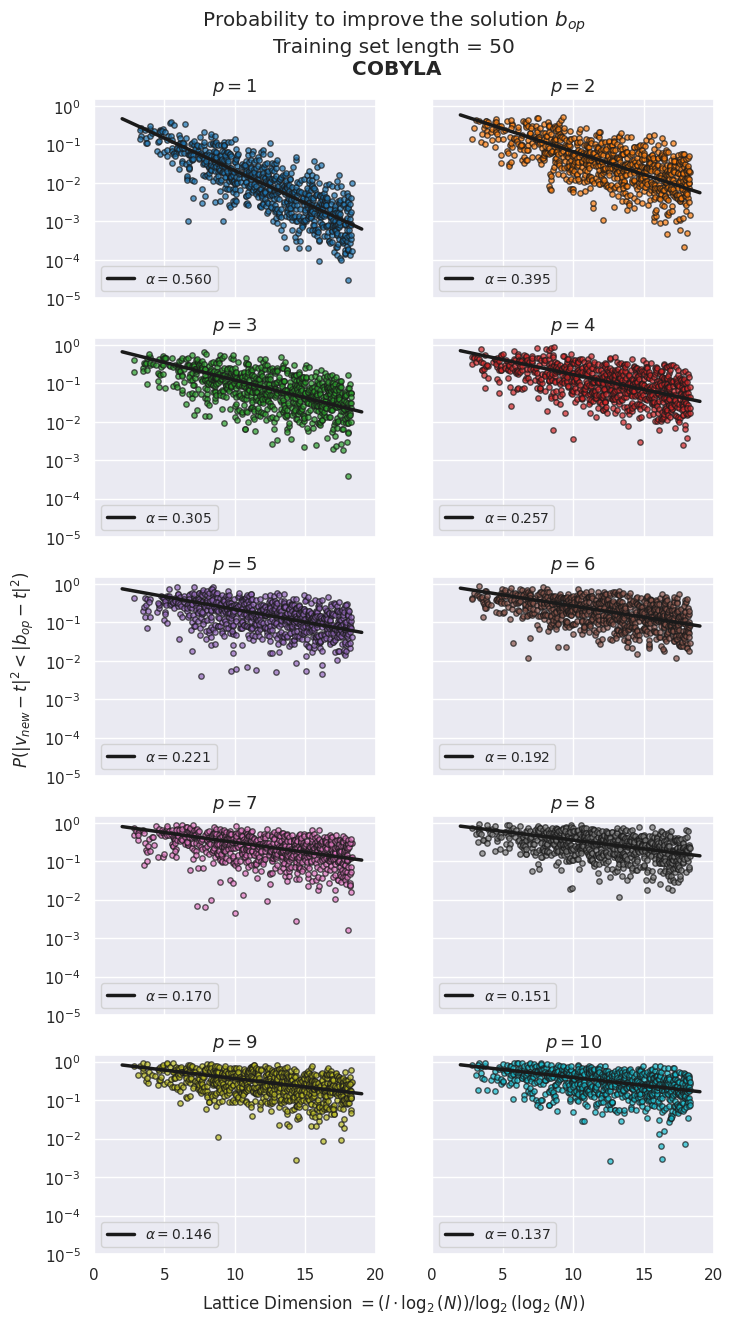

In [50]:
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(8, 15),
    sharey = 'row', sharex = 'col'
)
axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1 
    ax = axes_flat[idx]
    color = PALETTE[idx]

    nelder_df = pd.read_csv(f"./results/scalability_results/datas2400_from9to128_2_COBYLA_p{p}.csv")

    #Tomo las probabilidades donde se ha encontrado vectores mejores
    nel_prob_positive = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    lattice_dimension = nel_prob_positive["Lattice_dimension"].to_numpy()
    probs = nel_prob_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    dimension_exacta = np.log2(nel_prob_positive["N"].to_numpy())/np.log2(np.log2(nel_prob_positive["N"].to_numpy()))

    ax.scatter(
        dimension_exacta, probs,
        color=color, s=15, zorder=2,
        edgecolor = 'k', alpha = 0.7
    )

    alpha = curve_fit(scaling_function, xdata = dimension_exacta, ydata = probs)[0][0]
 
 
    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)
    ys_successful = [scaling_function(x, alpha) for x in xs]

    sns.lineplot(x=xs, y=ys_successful, color='k', ax=ax, label=f'$\\alpha={alpha:.3f}$', zorder = 4, linewidth = 2.5)


    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])
    ax.legend(fontsize=10, loc="lower left")
    

fig.suptitle(
    "Probability to improve the solution $b_{op}$\nTraining set length = 50\n $\mathbf{COBYLA}$",
    y=0.94
)

fig.supylabel(
    r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
    fontsize=12,
    x=0.02  # ajusta la distancia horizontal al borde izquierdo
)
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.07  
)

plt.savefig('./figures/scalability_datas2400_from9to128_2_COBYLA_.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
for p in range(1, 11):
    cobyla_df = pd.read_csv(f"./results/scalability_results/datas2400_from9to128_2_COBYLA_p{p}.csv")
    nelder_df = pd.read_csv(f"./results/scalability_results/datas2400_from9to128_2_NelderMead_p{p}.csv")

    cob_prob_pos = cobyla_df[cobyla_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    nel_prob_pos = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

    alpha_cob = curve_fit(scaling_function, xdata = cob_prob_pos["Lattice_dimension"].to_numpy(), ydata = cob_prob_pos["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy())[0][0]
    alpha_nel = curve_fit(scaling_function, xdata = nel_prob_pos["Lattice_dimension"].to_numpy(), ydata = nel_prob_pos["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy())[0][0]


    print(f"p = {p}. COBYLA = {alpha_cob}")
    print(f"p = {p}. NelderMead = {alpha_nel}")

p = 1. COBYLA = 0.558013951255834
p = 1. NelderMead = 0.5766316857147902
p = 2. COBYLA = 0.39351241261345354
p = 2. NelderMead = 0.3948278884619844
p = 3. COBYLA = 0.3038716387118553
p = 3. NelderMead = 0.3034415445702048
p = 4. COBYLA = 0.25701029284796906
p = 4. NelderMead = 0.2634237282898029
p = 5. COBYLA = 0.2212305016301443
p = 5. NelderMead = 0.25242235983278394
p = 6. COBYLA = 0.19186077132621943
p = 6. NelderMead = 0.21516656248687396
p = 7. COBYLA = 0.16974961740142566
p = 7. NelderMead = 0.22210702068512894
p = 8. COBYLA = 0.15075124384909516
p = 8. NelderMead = 0.19103144909673736
p = 9. COBYLA = 0.14569217709842058
p = 9. NelderMead = 0.24827698637683576
p = 10. COBYLA = 0.1366707821910751
p = 10. NelderMead = 0.15825837943715737
